In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from matplotlib import colors
import warnings
from matplotlib import pyplot as plt
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

In [3]:
#First five rows of dataset
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
#Last five rows of dataset
df.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


In [5]:
#Shape of the DataFrame
df.shape

(2240, 29)

In [6]:
#Column Names
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [7]:
#General info about DataSet
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Some rows in Income column can be seen as null, missing value, to remove the missing values .dropna() is going to be used.

In [8]:
nunique = df.nunique()
nunique

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

It can be seen that Z_CostContact and Z_Revenue variables have single value. As these variables is going to be useless, that varibles can be dropped.

In [9]:
df.drop(['Z_CostContact' ,'Z_Revenue'] , axis = 1 , inplace=True)

In [10]:
df = df.dropna()
print("After deleting rows which have missing value,\nTotal number of remaining (cleaned) rows is :", len(df))

After deleting rows which have missing value,
Total number of remaining (cleaned) rows is : 2216


In [11]:
print("The richest customer's yearly household income :", df['Income'].max())
print("The poorest customer's yearly household income: ",df['Income'].min())

The richest customer's yearly household income : 666666.0
The poorest customer's yearly household income:  1730.0


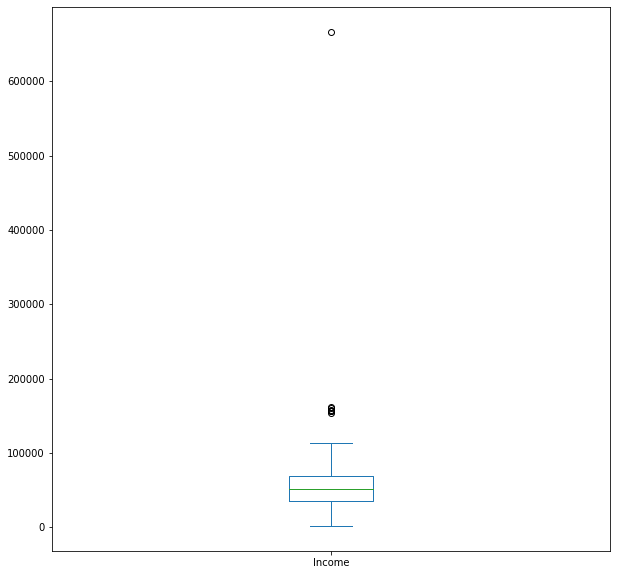

In [12]:
df['Income'].plot.box(figsize= (10,10))
plt.show()

In [13]:
print("Distribution of customers by year of birth is listed below \n", df['Year_Birth'].value_counts())


Distribution of customers by year of birth is listed below 
 1976    89
1971    86
1975    83
1972    78
1978    76
1970    75
1965    74
1973    72
1969    70
1974    69
1956    55
1979    53
1958    52
1977    52
1952    52
1968    51
1966    50
1959    50
1954    49
1960    49
1955    48
1982    44
1963    44
1962    44
1967    44
1951    42
1983    41
1986    41
1957    41
1964    41
1980    39
1981    38
1984    38
1961    35
1953    35
1985    32
1949    30
1989    29
1988    29
1950    29
1987    27
1948    21
1990    18
1946    16
1947    16
1991    15
1992    13
1945     8
1944     7
1943     6
1995     5
1993     5
1994     3
1996     2
1899     1
1941     1
1893     1
1900     1
1940     1
Name: Year_Birth, dtype: int64


<AxesSubplot:>

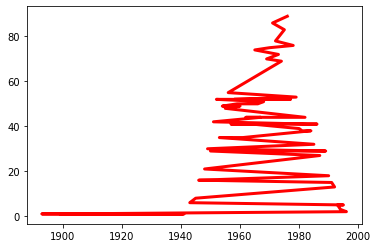

In [14]:
df['Year_Birth'].value_counts().plot(kind='line', color = 'red', linewidth =3)


In [15]:
#Here we are calculating the age of the customers from their birth year.

df['Age'] = 2022-df['Year_Birth']

In [74]:
#Dt_Customer is the tenure of the customer. Which means number of days customer was engaged with company
df['Dt_Customer'] = pd.to_datetime(df.Dt_Customer)
df['Today'] = '01-01-2022'
df['Today'] = pd.to_datetime(df.Today)
df['Tenure'] = (df['Today'] - df['Dt_Customer']).dt.days

In [16]:
#Calculating the number of children 
df['Children'] = df['Kidhome']+df['Teenhome']

In [17]:
print("And here we can see that    \n", df.groupby(by = 'Children').Age.mean())

And here we can see that    
 Children
0    53.415482
1    51.625783
2    56.269231
3    59.200000
Name: Age, dtype: float64


By looking at this comparison, we can say that +55 y/o have more children than the others.

In [18]:
df['Marital_Status'].value_counts()

Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: Marital_Status, dtype: int64

<AxesSubplot:>

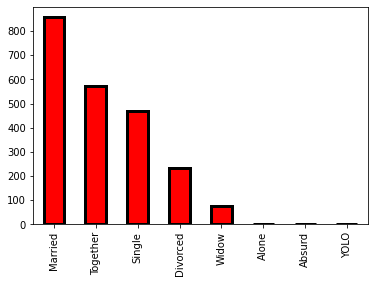

In [19]:
df['Marital_Status'].value_counts().plot(kind = 'bar', color = 'red', edgecolor = 'black', linewidth =3)

So we can see that there are 8 different categories as Marital Status. These can be segmented.

In [20]:
df['Marital_Status'] = df['Marital_Status'].replace(['Divorced', 'Widow','Alone','YOLO','Absurd'],'Single')
df['Marital_Status'] = df['Marital_Status'].replace({'Married' : 'Relationship', 'Together': 'Relationship'})

In [21]:
df['Marital_Status'].unique()

array(['Single', 'Relationship'], dtype=object)

Now, Marital Status are more clear, customers are single, or in a relationship.

In [22]:
df['Marital_Status'].value_counts()

Relationship    1430
Single           786
Name: Marital_Status, dtype: int64

In [23]:
df['Is_Single'] = df['Marital_Status'].copy()


In [24]:
df['Is_Single'].replace({'Relationship': '0'}, inplace = True)
df['Is_Single'].replace({'Single': '1'}, inplace = True)
print(df['Is_Single'])

0       1
1       1
2       0
3       0
4       0
       ..
2235    0
2236    0
2237    1
2238    0
2239    0
Name: Is_Single, Length: 2216, dtype: object


In [25]:
#Now we are checking the Education categories.
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

Only 'Basic' can be counted as under graduate. So segmentation can be done here.

In [26]:
df['Education'] = df['Education'].replace(['PhD', '2n Cycle','Master','Graduation'], 'PostGraduate')
df['Education'] = df['Education'].replace({'Basic': 'UnderGraduate'})

In [27]:
df['Education'].unique()

array(['PostGraduate', 'UnderGraduate'], dtype=object)

In [28]:
df['Education'].value_counts()

PostGraduate     2162
UnderGraduate      54
Name: Education, dtype: int64

<AxesSubplot:>

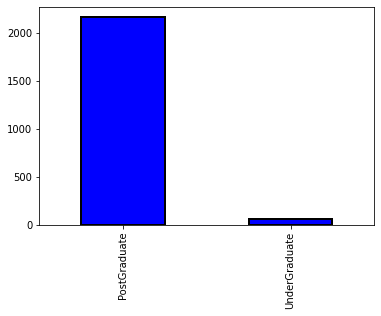

In [29]:
df['Education'].value_counts().plot(kind = 'bar', color = 'blue', edgecolor = 'black', linewidth =2)

This segmentation clarifies the most of the customers are graduated from school

In [30]:
#Total Spendings
df["Spendings"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"] 

In [31]:
#Minimum Spending
df['Spendings'].min()

5

In [32]:
#Maximum Spending
df['Spendings'].max()

2525

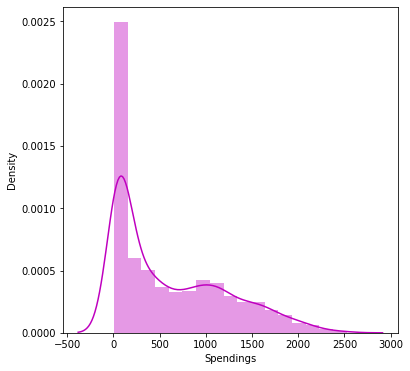

In [33]:
plt.figure(figsize = (6,6))
sns.distplot(df['Spendings'], color =  'm')
plt.show()

In [34]:
df['AcceptedCampaigns'] = df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] + df['AcceptedCmp4'] + df['AcceptedCmp5']

<AxesSubplot:>

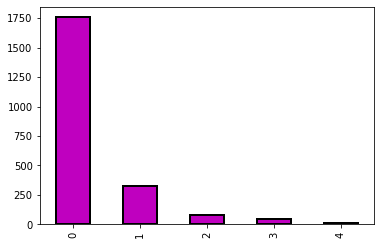

In [35]:
df['AcceptedCampaigns'].value_counts().plot(kind='bar',color = 'm',edgecolor = "black",linewidth = 2)

That graph indicates that most of the customers did not accept any of the campaings.

In [36]:
df['TotalPurchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'] + df['NumDealsPurchases']

In [37]:
df['TotalPurchases'].value_counts()

7     148
5     143
4     125
6     123
17    115
16    101
19    100
9     100
21     94
20     94
8      93
22     93
23     87
18     79
10     78
15     72
12     70
26     67
25     67
11     66
24     55
14     54
13     44
27     38
28     35
29     18
32     12
31     11
30     11
33      4
34      4
0       4
2       3
1       3
37      1
43      1
35      1
39      1
44      1
Name: TotalPurchases, dtype: int64

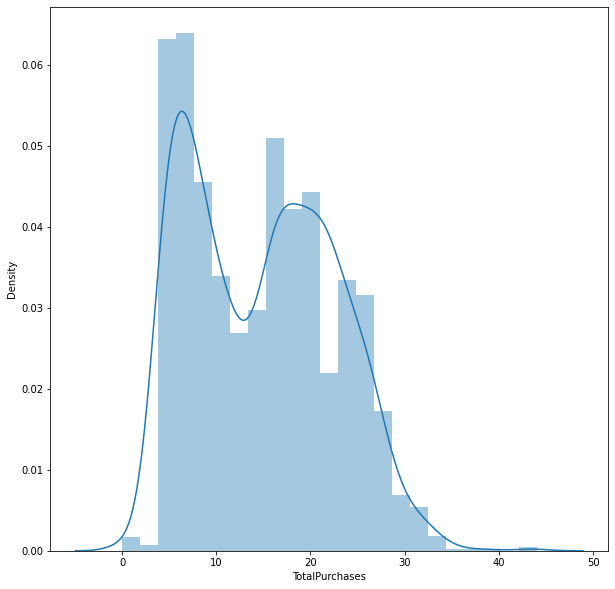

In [38]:
plt.figure(figsize=(10,10))
sns.distplot(df['TotalPurchases'])
plt.show()

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2216 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   object 
 3   Marital_Status       2216 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   object 
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null   int64  
 15  NumDealsPurchases    2216 non-null   i

Here we can see the new columns. As Age column is created, Year_Birth can be dropped.

<Figure size 432x288 with 0 Axes>

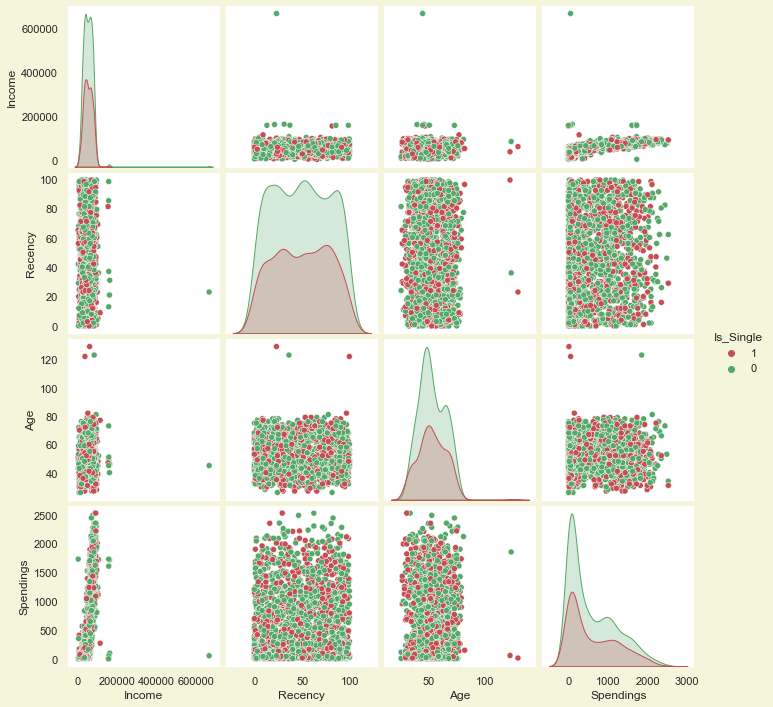

In [40]:
sns.set(rc={"axes.facecolor":"w","figure.facecolor":"beige"})
Plot = ["Income" ,"Recency", "Age", "Spendings", "Is_Single" ]
plt.figure()
sns.pairplot(df[Plot], hue= "Is_Single",palette= (["r","g"]))
plt.show()

There are some outliers in features. These outliers can be deleted by setting the range.

In [41]:
df = df[(df["Income"]<50000)]
df = df[(df["Age"]<85)]


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1059 entries, 1 to 2234
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   1059 non-null   int64  
 1   Year_Birth           1059 non-null   int64  
 2   Education            1059 non-null   object 
 3   Marital_Status       1059 non-null   object 
 4   Income               1059 non-null   float64
 5   Kidhome              1059 non-null   int64  
 6   Teenhome             1059 non-null   int64  
 7   Dt_Customer          1059 non-null   object 
 8   Recency              1059 non-null   int64  
 9   MntWines             1059 non-null   int64  
 10  MntFruits            1059 non-null   int64  
 11  MntMeatProducts      1059 non-null   int64  
 12  MntFishProducts      1059 non-null   int64  
 13  MntSweetProducts     1059 non-null   int64  
 14  MntGoldProds         1059 non-null   int64  
 15  NumDealsPurchases    1059 non-null   i

<AxesSubplot:>

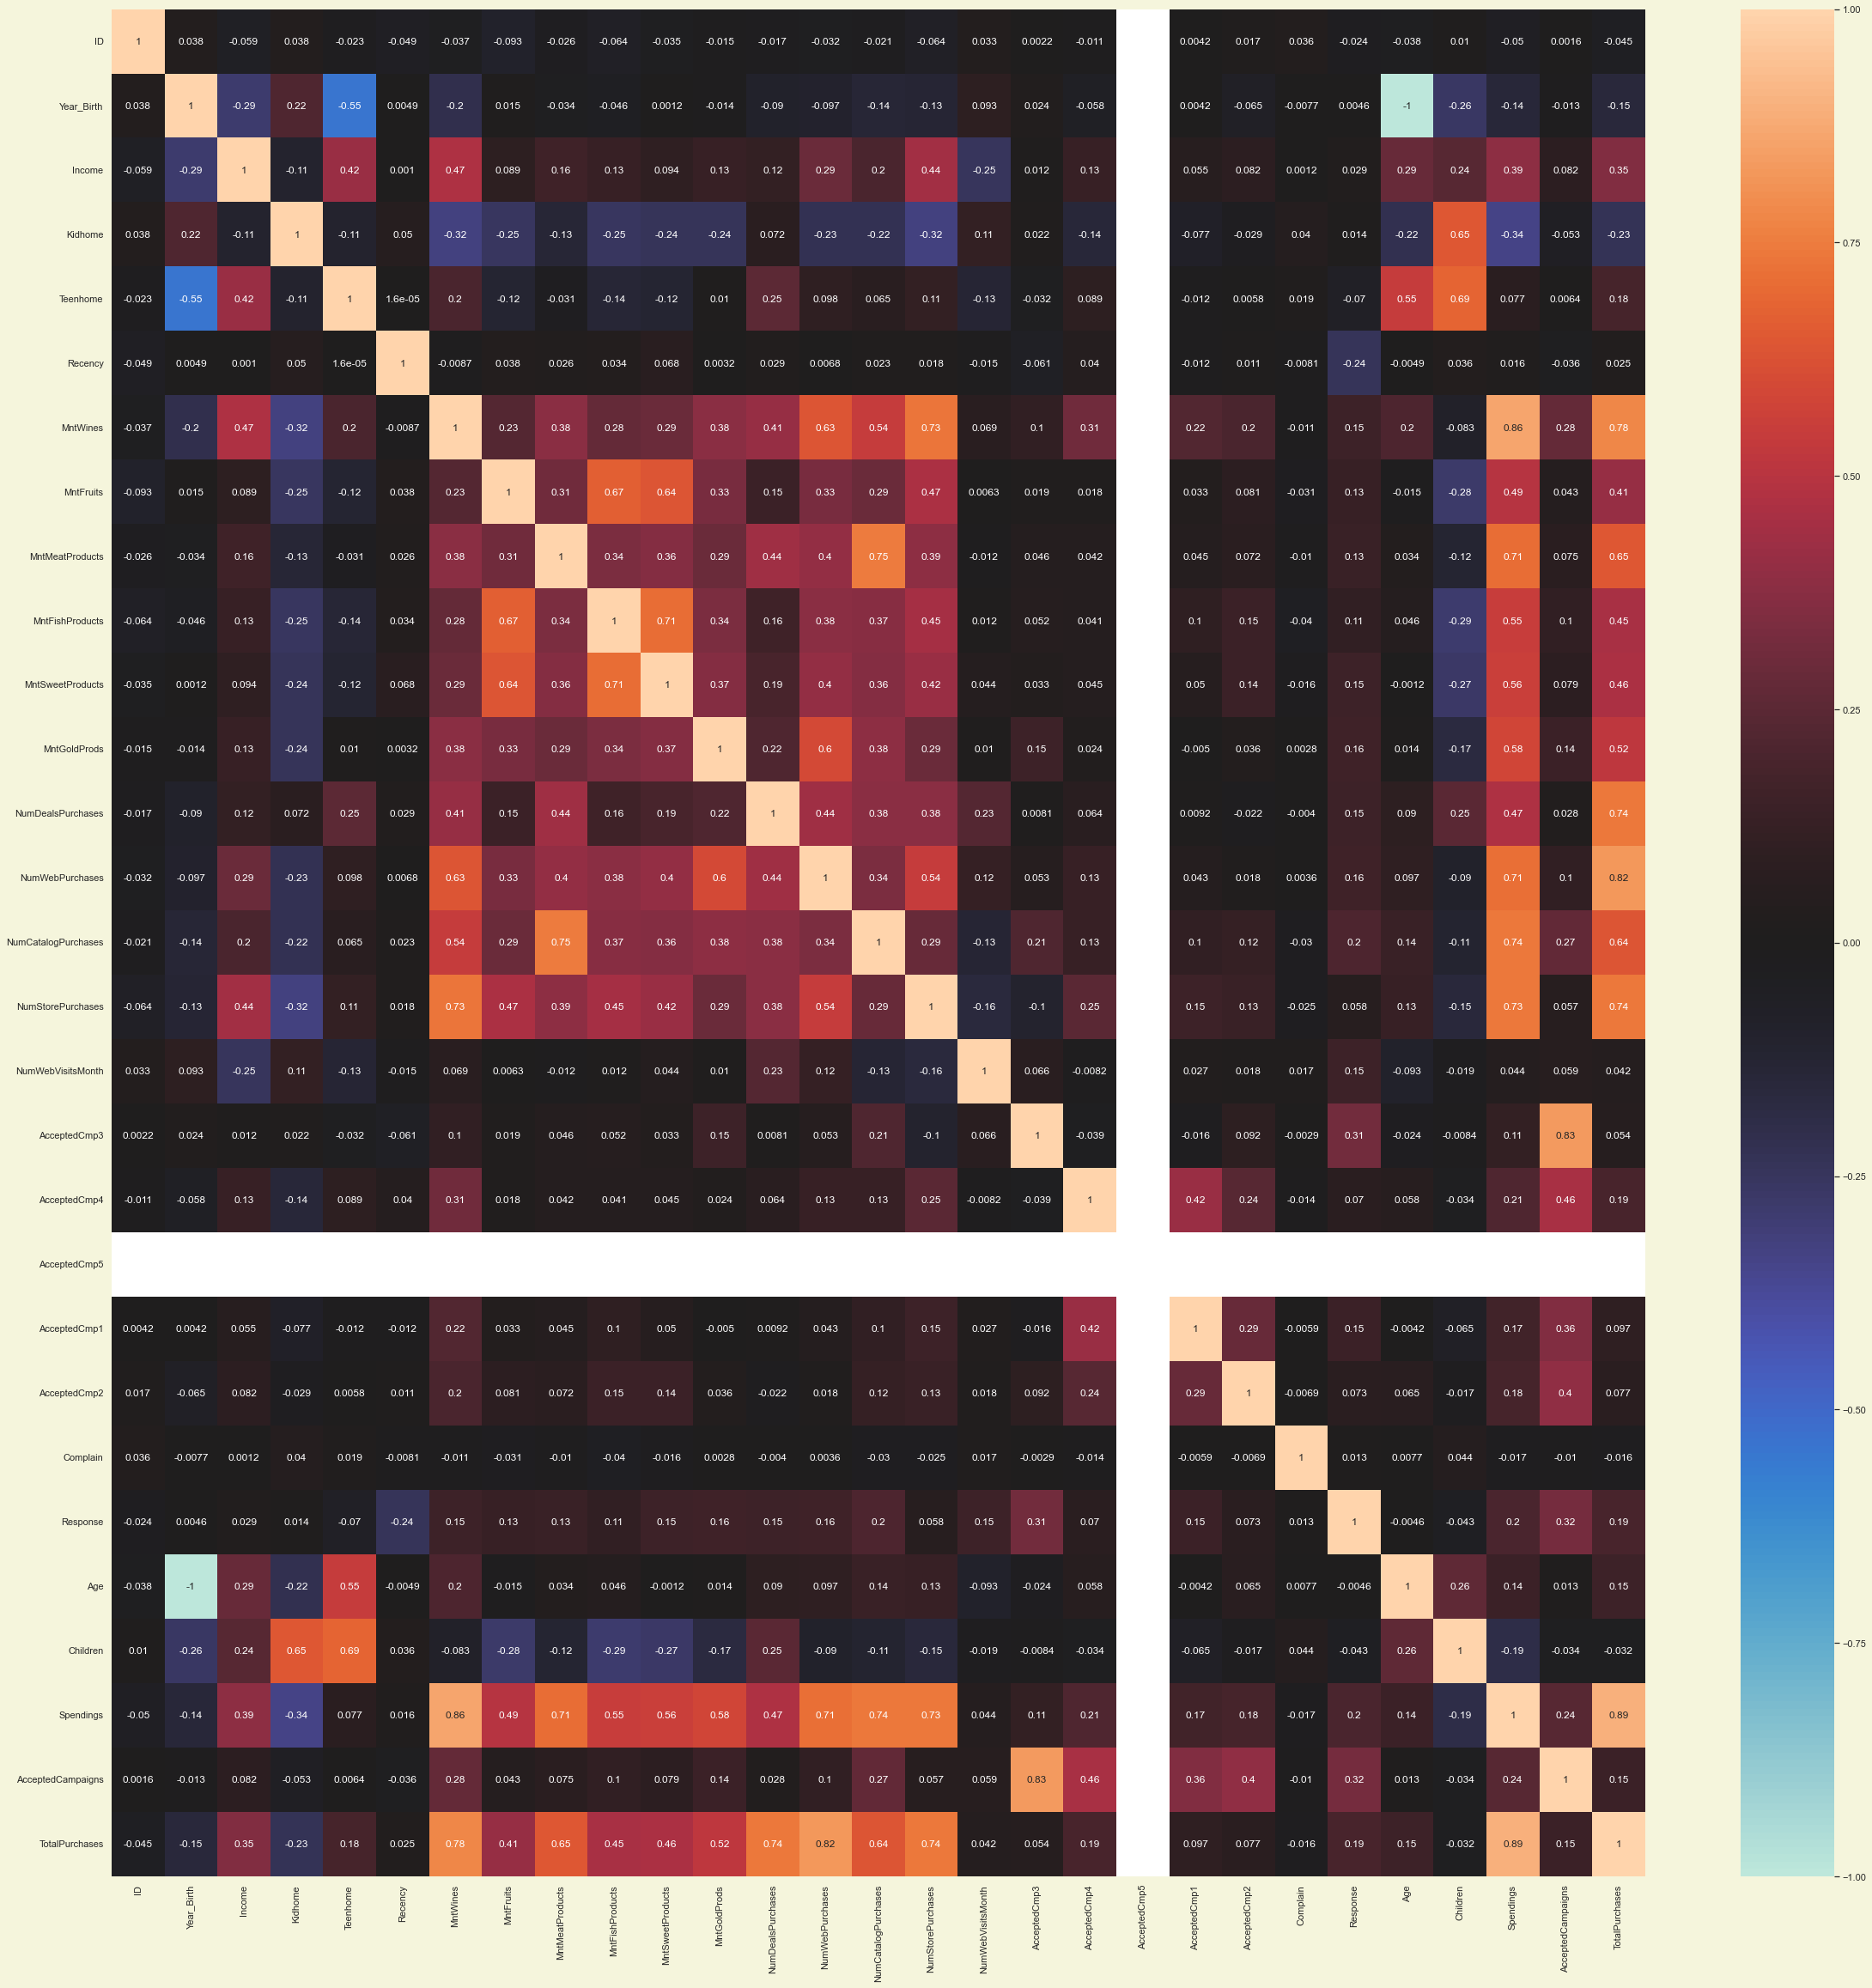

In [43]:
cor=df.corr()
plt.figure(figsize=(30,30))
sns.heatmap(cor, annot = True, center=0)

As there are too much features, deleting some columns to reduce complexity of the model

In [44]:
col_del = ["AcceptedCmp1" , "AcceptedCmp2", "AcceptedCmp3" , "AcceptedCmp4","AcceptedCmp5","NumWebVisitsMonth", "NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumDealsPurchases" , "Kidhome", "Teenhome","MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds", "Marital_Status", "Year_Birth"]
df=df.drop(columns = col_del)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1059 entries, 1 to 2234
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID                 1059 non-null   int64         
 1   Education          1059 non-null   object        
 2   Income             1059 non-null   float64       
 3   Dt_Customer        1059 non-null   datetime64[ns]
 4   Recency            1059 non-null   int64         
 5   Complain           1059 non-null   int64         
 6   Response           1059 non-null   int64         
 7   Age                1059 non-null   int64         
 8   Children           1059 non-null   int64         
 9   Is_Single          1059 non-null   object        
 10  Spendings          1059 non-null   int64         
 11  AcceptedCampaigns  1059 non-null   int64         
 12  TotalPurchases     1059 non-null   int64         
 13  Today              1059 non-null   datetime64[ns]
 14  Tenure  

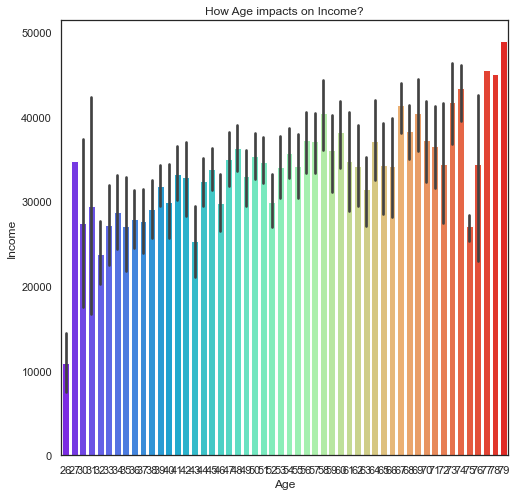

In [62]:
plt.figure(figsize=(8,8))
plt.title("How Age impacts on Income?")
ax = sns.barplot(x="Age", y="Income", data=df,palette="rainbow")

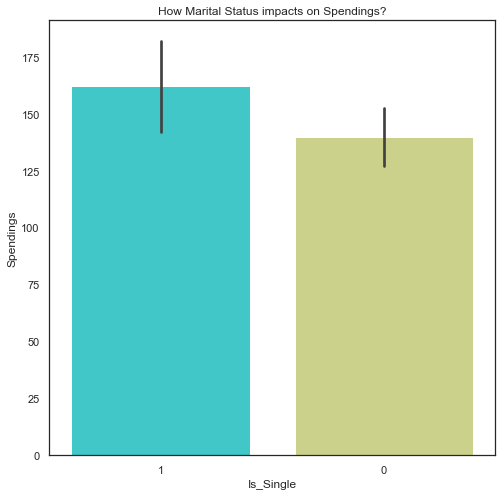

In [65]:

plt.figure(figsize=(8,8))
plt.title("How Marital Status impacts on Spendings?")
ax = sns.barplot(x="Is_Single", y="Spendings", data=df,palette="rainbow")

<AxesSubplot:>

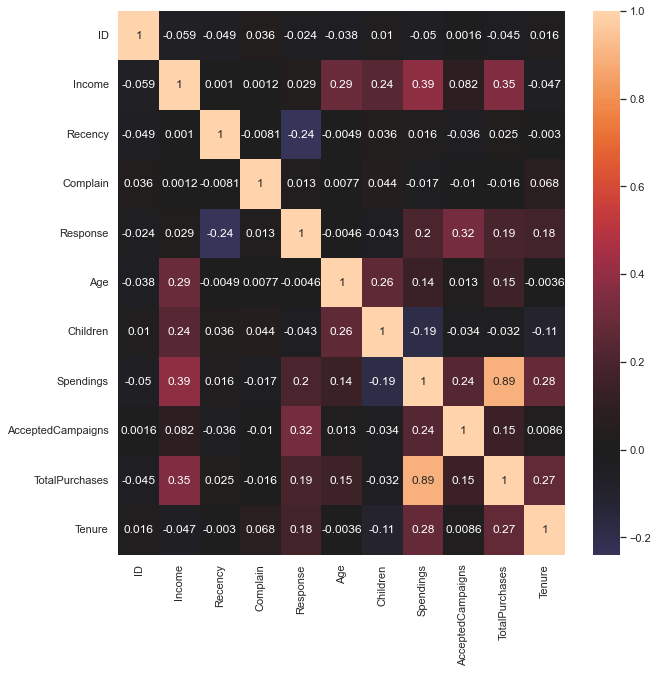

In [81]:
#Checking the correlation with the cleaned data
cor=df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(cor, annot = True, center=0)

## DATA PREPROCESSING

Categorical variables in the dataset: ['Education', 'Dt_Customer', 'Is_Single']


In [85]:
col_del2 = ["Dt_Customer", "Today"]
df=df.drop(columns = col_del2)

In [86]:
df.dtypes

ID                     int64
Education             object
Income               float64
Recency                int64
Complain               int64
Response               int64
Age                    int64
Children               int64
Is_Single             object
Spendings              int64
AcceptedCampaigns      int64
TotalPurchases         int64
Tenure                 int64
dtype: object

In [89]:
#Object types
s = (df.dtypes == 'object')
object_cols = list(s[s].index)
print("Objects in the dataset:", object_cols)

Objects in the dataset: ['Education', 'Is_Single']


In [90]:
#Integer types
s = (df.dtypes == 'int64')
integer_cols = list(s[s].index)
print("Integers in the dataset:", integer_cols)

Integers in the dataset: ['ID', 'Recency', 'Complain', 'Response', 'Age', 'Children', 'Spendings', 'AcceptedCampaigns', 'TotalPurchases', 'Tenure']


Bu bir denemedir
